# <font color='dark'>**Classificação: Validação de modelos e métricas de avaliação**</h1>

### Projeto

Uma empresa de empréstimo de automóveis está passando por uma situação complicada, com alta demanda para uma frota reduzida de veículos e alto número de inadimplentes, trazendo um prejuízo grande para a empresa.

Nós fomos contratados para buscar melhorias na identificação de inadimplentes. A análise dos clientes atualmente é feita de forma manual, cliente por cliente, tomando muito tempo e ainda assim a detecção de inadimplentes é muito imprecisa.

Nossa tarefa é utilizar os dados fornecidos pela empresa para **classificar** os clientes em adimplentes e inadimplentes.

## <font color='dark'>Classificando dados</h1>

### Criando um modelo inicial

In [1]:
import pandas as pd

In [2]:
dados = pd.read_csv('emp_automovel.csv')
dados.head()

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,12600.0,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.0,0
1,9000.0,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.0,0
2,15750.0,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.0,0
3,9000.0,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.0,0
4,7650.0,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.0,0


In [4]:
x = dados.drop('inadimplente', axis=1)
y = dados['inadimplente']

In [5]:
from sklearn.tree import DecisionTreeClassifier

In [6]:
modelo = DecisionTreeClassifier()
modelo.fit(x, y)
modelo.score(x, y)

1.0

In [7]:
print(f'Acurácia: {modelo.score(x, y):.2%}')

Acurácia: 100.00%


In [8]:
from sklearn.model_selection import train_test_split

In [10]:
x, x_teste, y, y_teste = train_test_split(x, y, test_size=0.15, stratify=y, random_state=5)
x_treino, x_val, y_treino, y_val = train_test_split(x, y, stratify=y, random_state=5)

In [11]:
modelo = DecisionTreeClassifier()
modelo.fit(x_treino, y_treino)
print(f'Acurácia de treino: {modelo.score(x_treino, y_treino):.2%}')
print(f'Acurácia de validação: {modelo.score(x_val, y_val):.2%}')

Acurácia de treino: 100.00%
Acurácia de validação: 85.36%


In [12]:
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(x_treino, y_treino)
print(f'Acurácia de treino: {modelo.score(x_treino, y_treino):.2%}')
print(f'Acurácia de validação: {modelo.score(x_val, y_val):.2%}')

Acurácia de treino: 92.23%
Acurácia de validação: 90.73%


In [13]:
from sklearn.metrics import confusion_matrix

In [14]:
y_previsto = modelo.predict(x_val)
matriz_confusao = confusion_matrix(y_val, y_previsto)
print(matriz_confusao)

[[8822   84]
 [ 821   31]]


In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

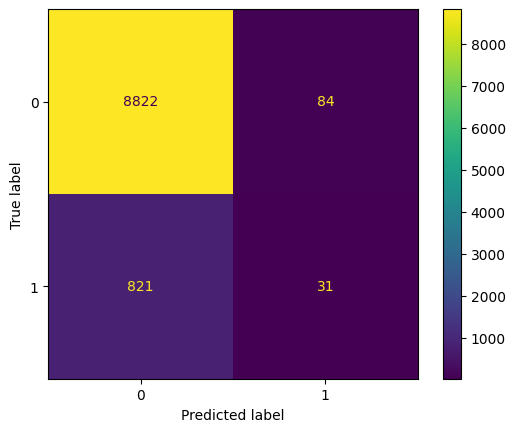

In [19]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix= matriz_confusao)
visualizacao.plot()

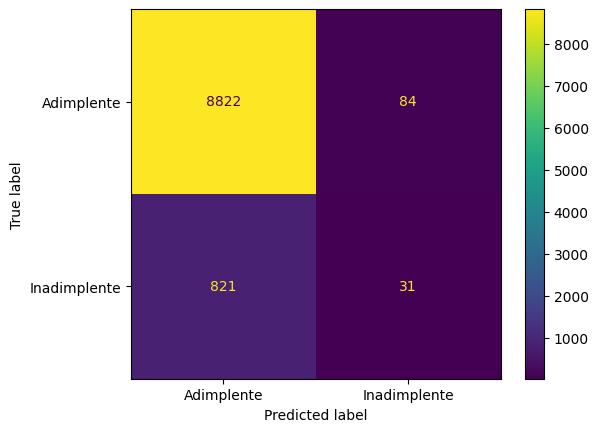

In [20]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix= matriz_confusao, display_labels=['Adimplente', 'Inadimplente'])
visualizacao.plot()

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
print(f'Acurácia: {accuracy_score(y_val, y_previsto):.2%}')

Acurácia: 90.73%


In [23]:
from sklearn.metrics import precision_score, recall_score

In [24]:
print(f'Precisão: {precision_score(y_val, y_previsto):.2%}')
print(f'Recall: {recall_score(y_val, y_previsto):.2%}')

Precisão: 26.96%
Recall: 3.64%


In [25]:
from sklearn.metrics import f1_score

In [26]:
print(f'F1_Score: {f1_score(y_val, y_previsto):.2%}')

F1_Score: 6.41%


In [27]:
from sklearn.metrics import RocCurveDisplay

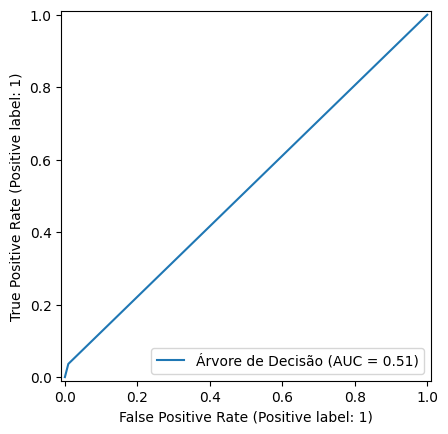

In [28]:
RocCurveDisplay.from_predictions(y_val, y_previsto, name='Árvore de Decisão')

In [29]:
from sklearn.metrics import roc_auc_score

In [30]:
print(f'AUC: {roc_auc_score(y_val, y_previsto):.2%}')

AUC: 51.35%


In [31]:
from sklearn.metrics import PrecisionRecallDisplay

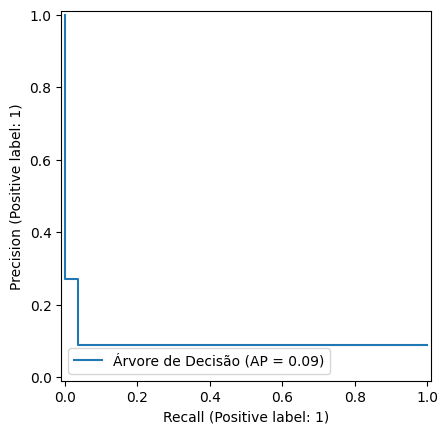

In [32]:
PrecisionRecallDisplay.from_predictions(y_val, y_previsto, name='Árvore de Decisão')

In [33]:
from sklearn.metrics import average_precision_score

In [34]:
print(f'AP: {average_precision_score(y_val, y_previsto):.2%}')

AP: 9.39%


In [35]:
from sklearn.metrics import classification_report

In [36]:
print(classification_report(y_val, y_previsto))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      8906
           1       0.27      0.04      0.06       852

    accuracy                           0.91      9758
   macro avg       0.59      0.51      0.51      9758
weighted avg       0.86      0.91      0.87      9758



In [37]:
from sklearn.model_selection import cross_validate, KFold

In [38]:
modelo = DecisionTreeClassifier(max_depth=10)
kf = KFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, x, y, cv=kf)
cv_resultados

{'fit_time': array([0.24482965, 0.23387623, 0.2284441 , 0.23197913, 0.2401576 ]),
 'score_time': array([0.00422001, 0.00326014, 0.00314856, 0.0036428 , 0.00790024]),
 'test_score': array([0.90239529, 0.90892789, 0.90507302, 0.9066103 , 0.91122214])}

In [39]:
cv_resultados['test_score']

array([0.90239529, 0.90892789, 0.90507302, 0.9066103 , 0.91122214])

In [40]:
media = cv_resultados['test_score'].mean()
desvio_padrao = cv_resultados['test_score'].std()
limite_inferior = media - 2 * desvio_padrao
limite_superior = min(media + 2 * desvio_padrao, 1)
print(f'Intervalo de confiança: [{limite_inferior:.2%}, {limite_superior:.2%}]')

Intervalo de confiança: [90.07%, 91.29%]


In [41]:
def intervalo_conf(resultados):
    media = resultados['test_score'].mean()
    desvio_padrao = resultados['test_score'].std()
    limite_inferior = media - 2 * desvio_padrao
    limite_superior = min(media + 2 * desvio_padrao, 1)
    return f'Intervalo de confiança: [{limite_inferior:.2%}, {limite_superior:.2%}]'

In [42]:
modelo = DecisionTreeClassifier(max_depth=10)
kf = KFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, x, y, cv=kf, scoring='recall')
cv_resultados

{'fit_time': array([0.28560352, 0.22757912, 0.22867322, 0.22786331, 0.28345346]),
 'score_time': array([0.00696802, 0.00587201, 0.00532627, 0.00541139, 0.00770593]),
 'test_score': array([0.02118644, 0.03742515, 0.02881844, 0.03174603, 0.01085271])}

In [43]:
intervalo_conf(cv_resultados)

'Intervalo de confiança: [0.76%, 4.44%]'

In [44]:
dados['inadimplente'].value_counts(normalize=True)

inadimplente
0    0.912707
1    0.087293
Name: proportion, dtype: float64

In [45]:
from sklearn.model_selection import StratifiedKFold

In [46]:
modelo = DecisionTreeClassifier(max_depth=10)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, x, y, cv=skf, scoring='recall')
cv_resultados

{'fit_time': array([0.3530767 , 0.18921852, 0.18993139, 0.20273638, 0.19150782]),
 'score_time': array([0.00561619, 0.00575447, 0.00728631, 0.00443149, 0.00445771]),
 'test_score': array([0.02199413, 0.01612903, 0.030837  , 0.04552129, 0.02932551])}

In [47]:
intervalo_conf(cv_resultados)

'Intervalo de confiança: [0.89%, 4.86%]'

In [49]:
from imblearn.over_sampling import SMOTE

In [50]:
oversampler = SMOTE()
x_balanceado, y_balanceado = oversampler.fit_resample(x, y)

In [51]:
y_balanceado.value_counts(normalize=True)

inadimplente
0    0.5
1    0.5
Name: proportion, dtype: float64

In [ ]:
modelo = DecisionTreeClassifier(max_depth=10)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, x_balanceado, y_balanceado, cv=skf, scoring='recall')

In [52]:
intervalo_conf(cv_resultados)

'Intervalo de confiança: [0.89%, 4.86%]'

In [53]:
from imblearn.pipeline import Pipeline as imbpipeline

In [54]:
modelo = DecisionTreeClassifier(max_depth=10)
pipeline = imbpipeline([('oversample', SMOTE()), ('arvore', modelo)])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(pipeline, x, y, cv=skf, scoring='recall')


In [55]:
intervalo_conf(cv_resultados)

'Intervalo de confiança: [21.68%, 28.32%]'

In [57]:
from imblearn.under_sampling import NearMiss

In [58]:
modelo = DecisionTreeClassifier(max_depth=10)
pipeline = imbpipeline([('undersample', NearMiss(version=3)), ('arvore', modelo)])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(pipeline, x, y, cv=skf, scoring='recall')

In [59]:
intervalo_conf(cv_resultados)

'Intervalo de confiança: [59.78%, 73.78%]'

              precision    recall  f1-score   support

           0       0.94      0.45      0.61      6288
           1       0.11      0.68      0.18       601

    accuracy                           0.47      6889
   macro avg       0.52      0.57      0.40      6889
weighted avg       0.86      0.47      0.57      6889



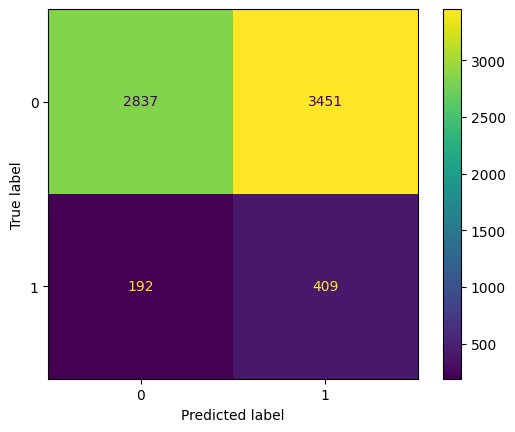

In [60]:
undersample = NearMiss(version=3)
x_balanceado, y_balanceado = undersample.fit_resample(x, y)

modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(x_balanceado, y_balanceado)
y_previsto = modelo.predict(x_teste)

print(classification_report(y_teste, y_previsto))
ConfusionMatrixDisplay.from_predictions(y_teste, y_previsto)